# **Лабораторная работа№1**
## **Разведочный анализ данных. Исследование и визуализация данных.**


### **1) Текстовое описание набора данных**
В качестве набора данных мы будем использовать набор данных "Качество красного вина" (https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009).
Набор данных состоит из файла winequality-red.csv.
В наборе данных содержатся следующие колонки:
Входные переменные (на основе физико-химических тестов):

- 1 — постоянная кислотность (fixed acidity) - большинство кислот, содержащихся в вине, являются фиксированными или нелетучими (не испаряются легко)
- 2 — летучая кислотность (volatile acidity) - количество уксусной кислоты в вине, избыток которой может привести к появлению неприятного уксусного вкуса
- 3 — лимонная кислота (citric acid) - лимонная кислота в небольших количествах может придавать винам «свежесть» и особый вкус
- 4 - остаточный сахар (residual sugar) - Количество сахара, остающегося после завершения брожения, редко превышает 1 грамм на литр, а вина с содержанием сахара более 45 граммов на литр считаются сладкими.
- 5 - хлориды (chlorides) - количество соли в вине
- 6 — свободный диоксид серы (free sulfur dioxide) - Свободная форма SO2 находится в равновесии между молекулярным SO2 (в виде растворенного газа) и бисульфит-ионом. Она препятствует росту микроорганизмов и окислению вина.
- 7 — общее количество диоксида серы (total sulfur dioxide) - количество свободных и связанных форм S02; при низких концентрациях SO2 практически не обнаруживается в вине, но при концентрации свободного SO2 более 50 ppm он начинает ощущаться в аромате и вкусе вина
- 8 - плотность (density) - плотность воды близка к плотности воды в зависимости от процентного содержания спирта и сахара
- 9 - pH (pH) - показывает, насколько вино кислое или щелочное, по шкале от 0 (очень кислое) до 14 (очень щелочное); большинство вин имеют показатель pH от 3 до 4
- 10 — сульфаты (sulphates) - grid_3x3сульфатысортировкавинная добавка, которая может повышать уровень диоксида серы (S02), действующего как противомикробное средство и антиоксидант
- 11 - алкоголь (alcohol) - процентное содержание алкоголя в вине

- 12 - качество (quality) (оценка от 0 до 10)  - Выходная переменная (на основе сенсорных данных)



Импортируем нужные библиотеки

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Загрузим данные из csv файла

In [20]:
data = pd.read_csv('winequality-red.csv', sep=",")

Отобразим первые строки таблицы

In [21]:

data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Отобразим типы данных

In [22]:
data.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Отобразим кол-во строк и колонок

In [23]:
data.shape

(1599, 12)

Проверим наличие пустых значений в каждой из колонок

In [24]:
for col in data.columns:
    temp_null_count = data[data[col].isnull()].shape[0]
    print('{} - {}'.format(col, temp_null_count))

fixed acidity - 0
volatile acidity - 0
citric acid - 0
residual sugar - 0
chlorides - 0
free sulfur dioxide - 0
total sulfur dioxide - 0
density - 0
pH - 0
sulphates - 0
alcohol - 0
quality - 0


Отобразим основные показатели датасета по колонкам

In [25]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


Визуальное исследование данных

Построим диаграмму рассеяния для pH

<Axes: xlabel='pH', ylabel='fixed acidity'>

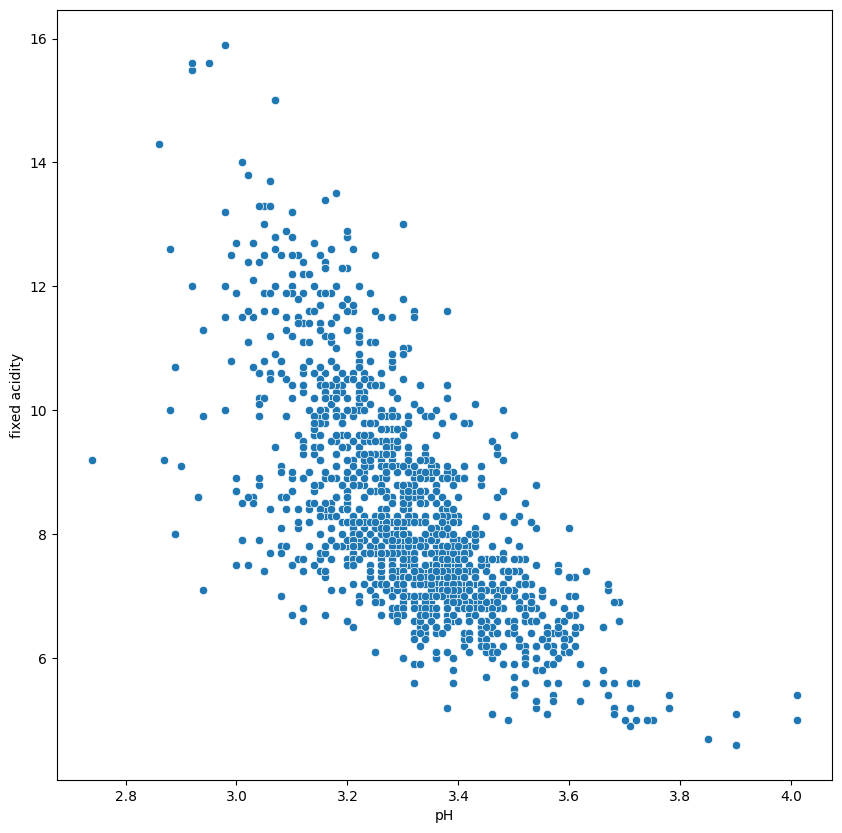

In [26]:
fig, ax = plt.subplots(figsize=(10,10)) 
sns.scatterplot(ax=ax, x='pH', y='fixed acidity', data=data)

Построим гистограмму для alcohol

<Axes: xlabel='alcohol', ylabel='Count'>

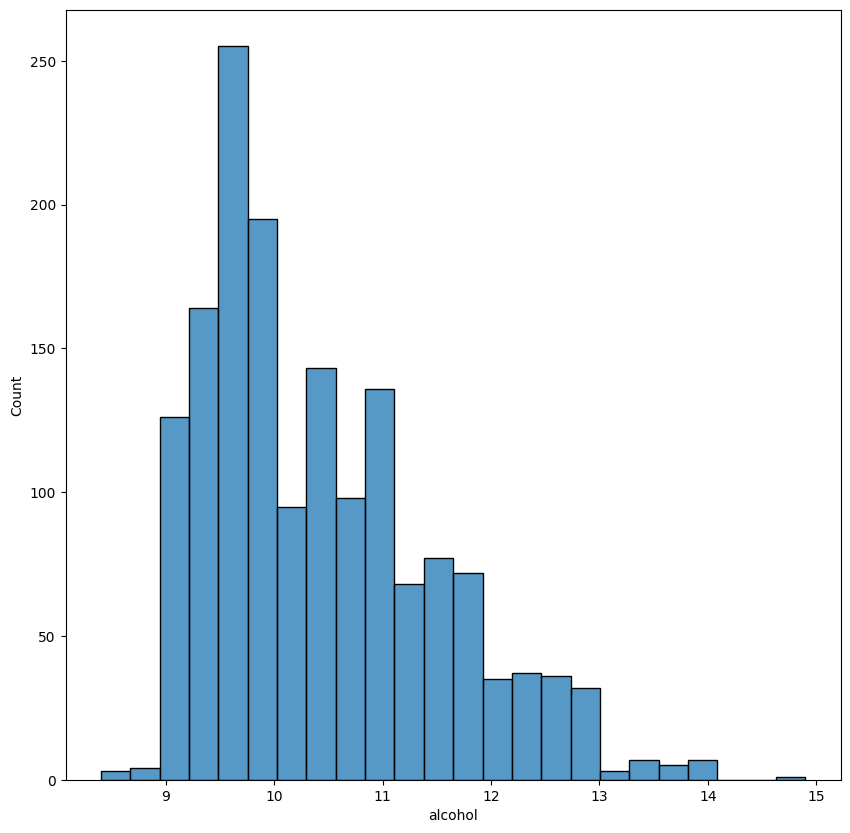

In [27]:
fig, ax = plt.subplots(figsize=(10,10)) 
sns.histplot(data['alcohol'])

Построим парные диаграммы для всего датасета

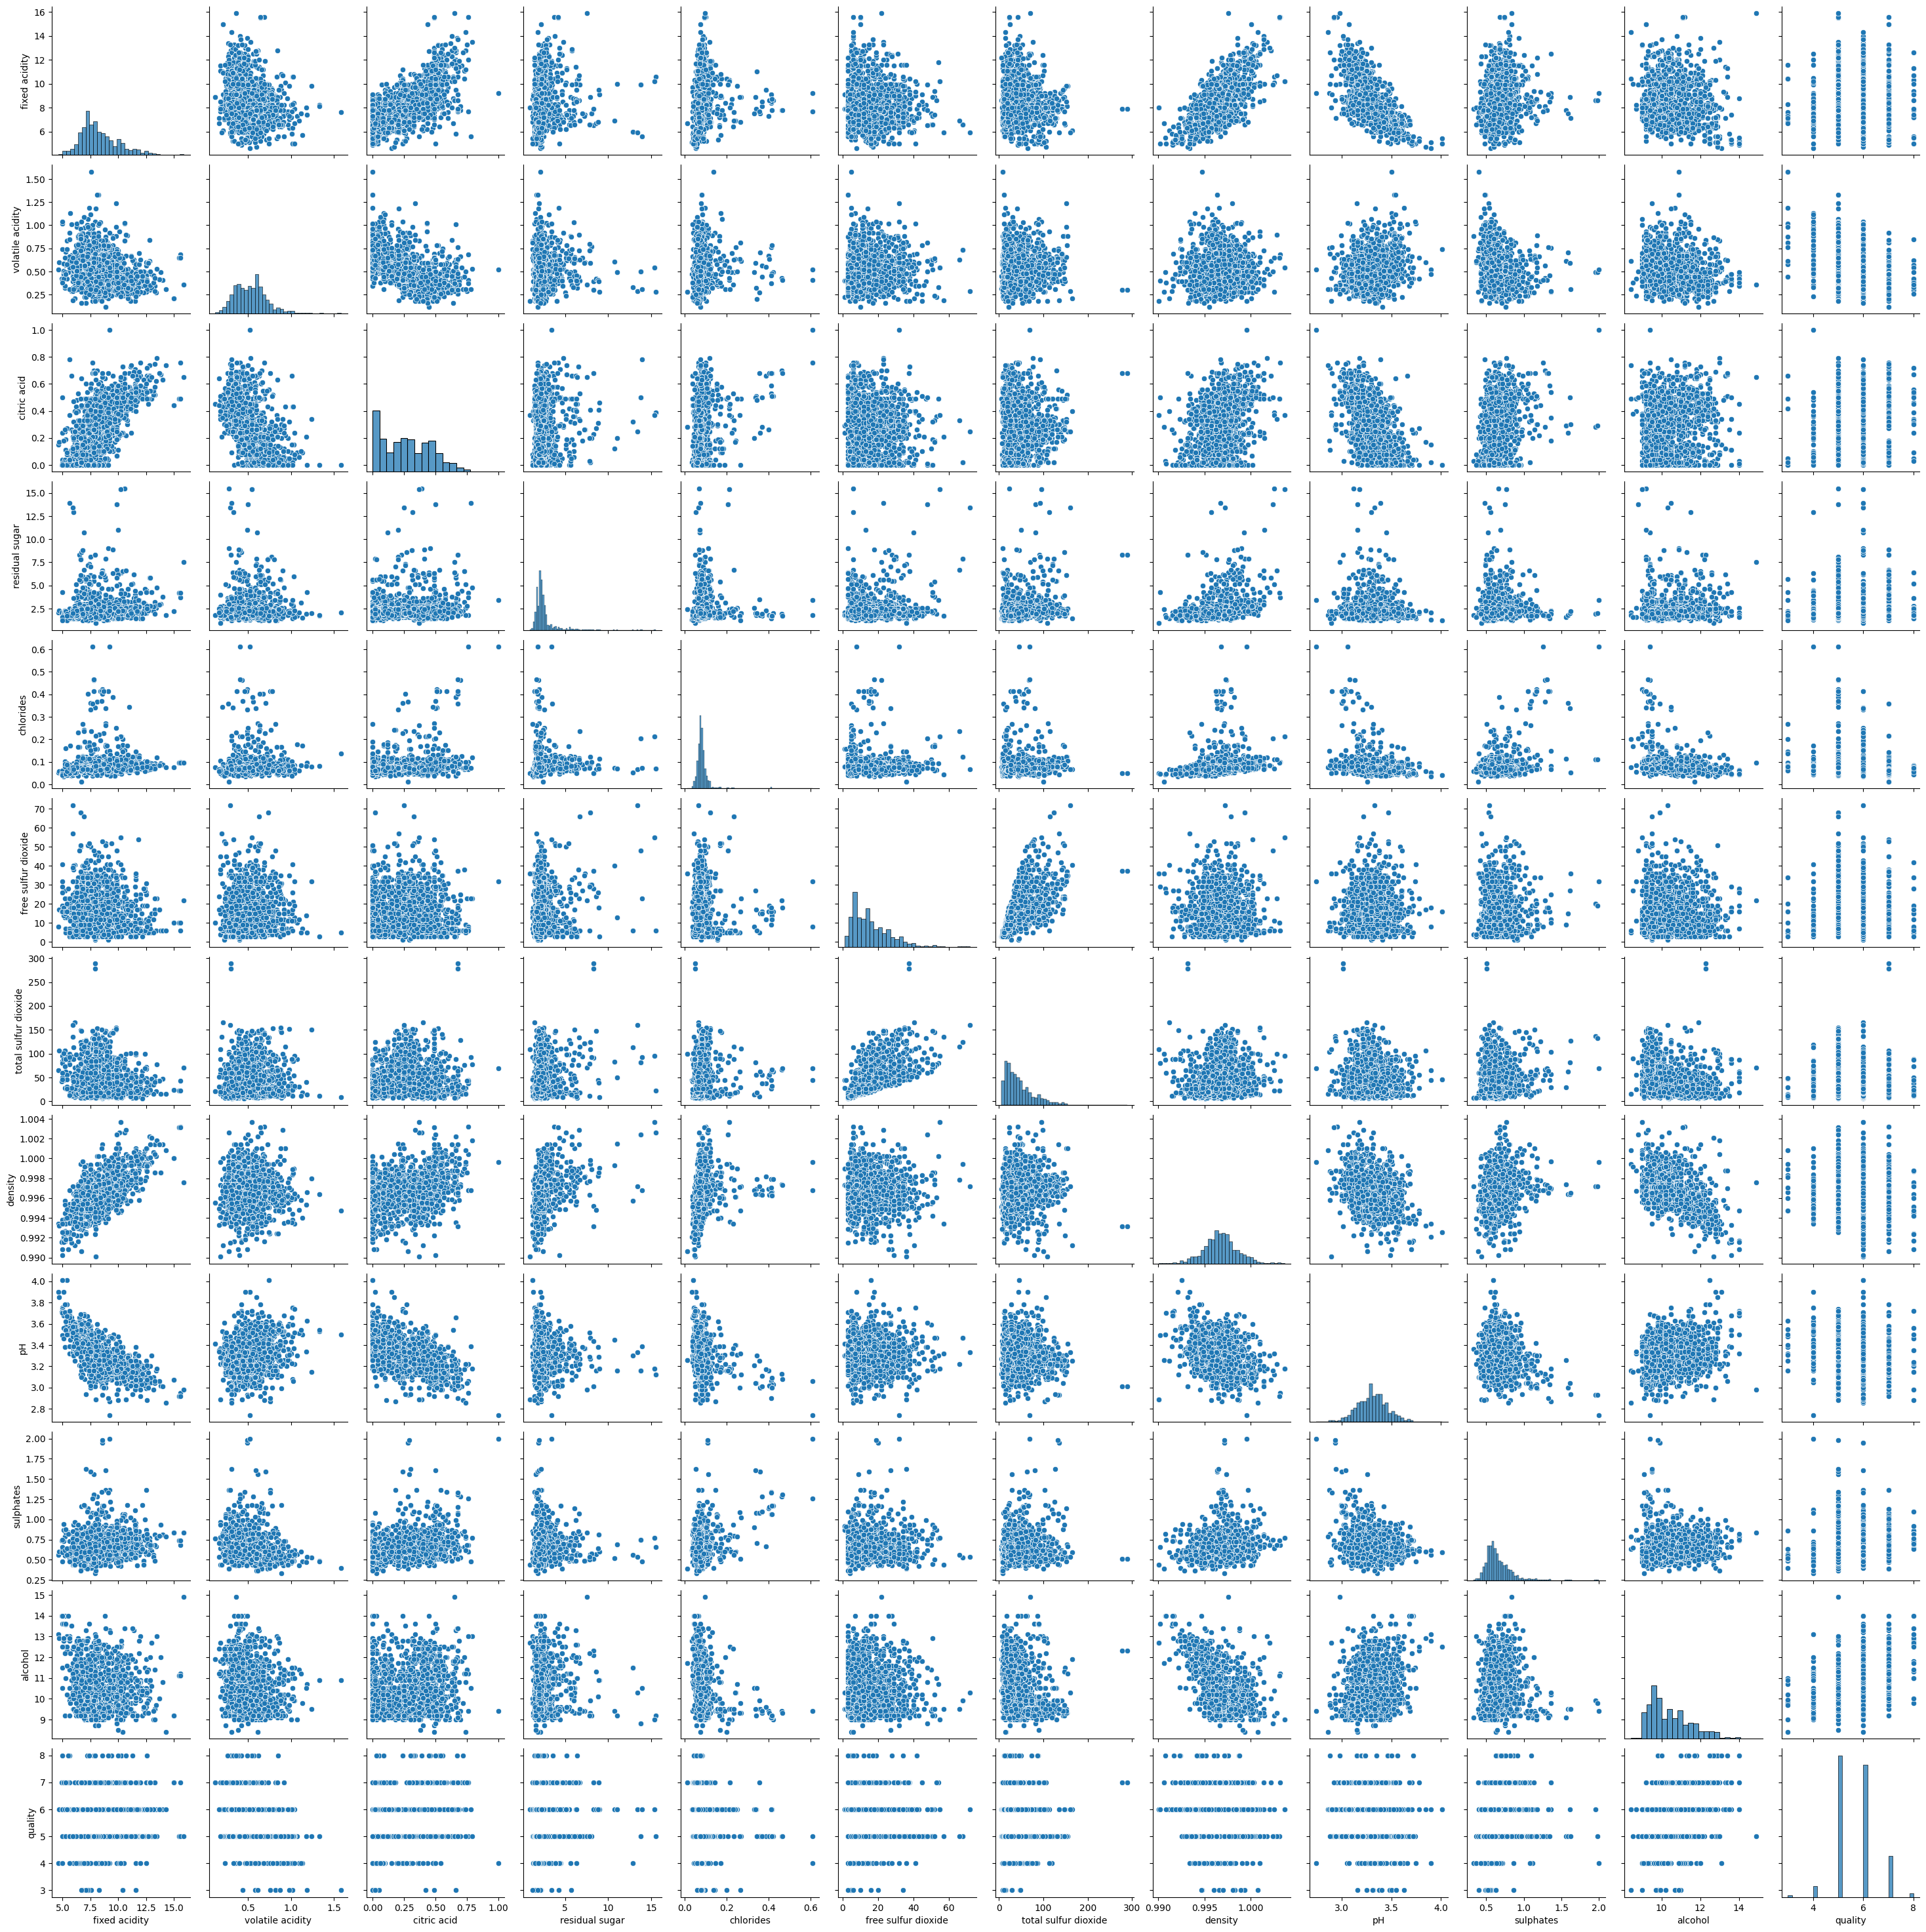

In [28]:
sns.pairplot(data)

Сгруппируем данные признаку качества

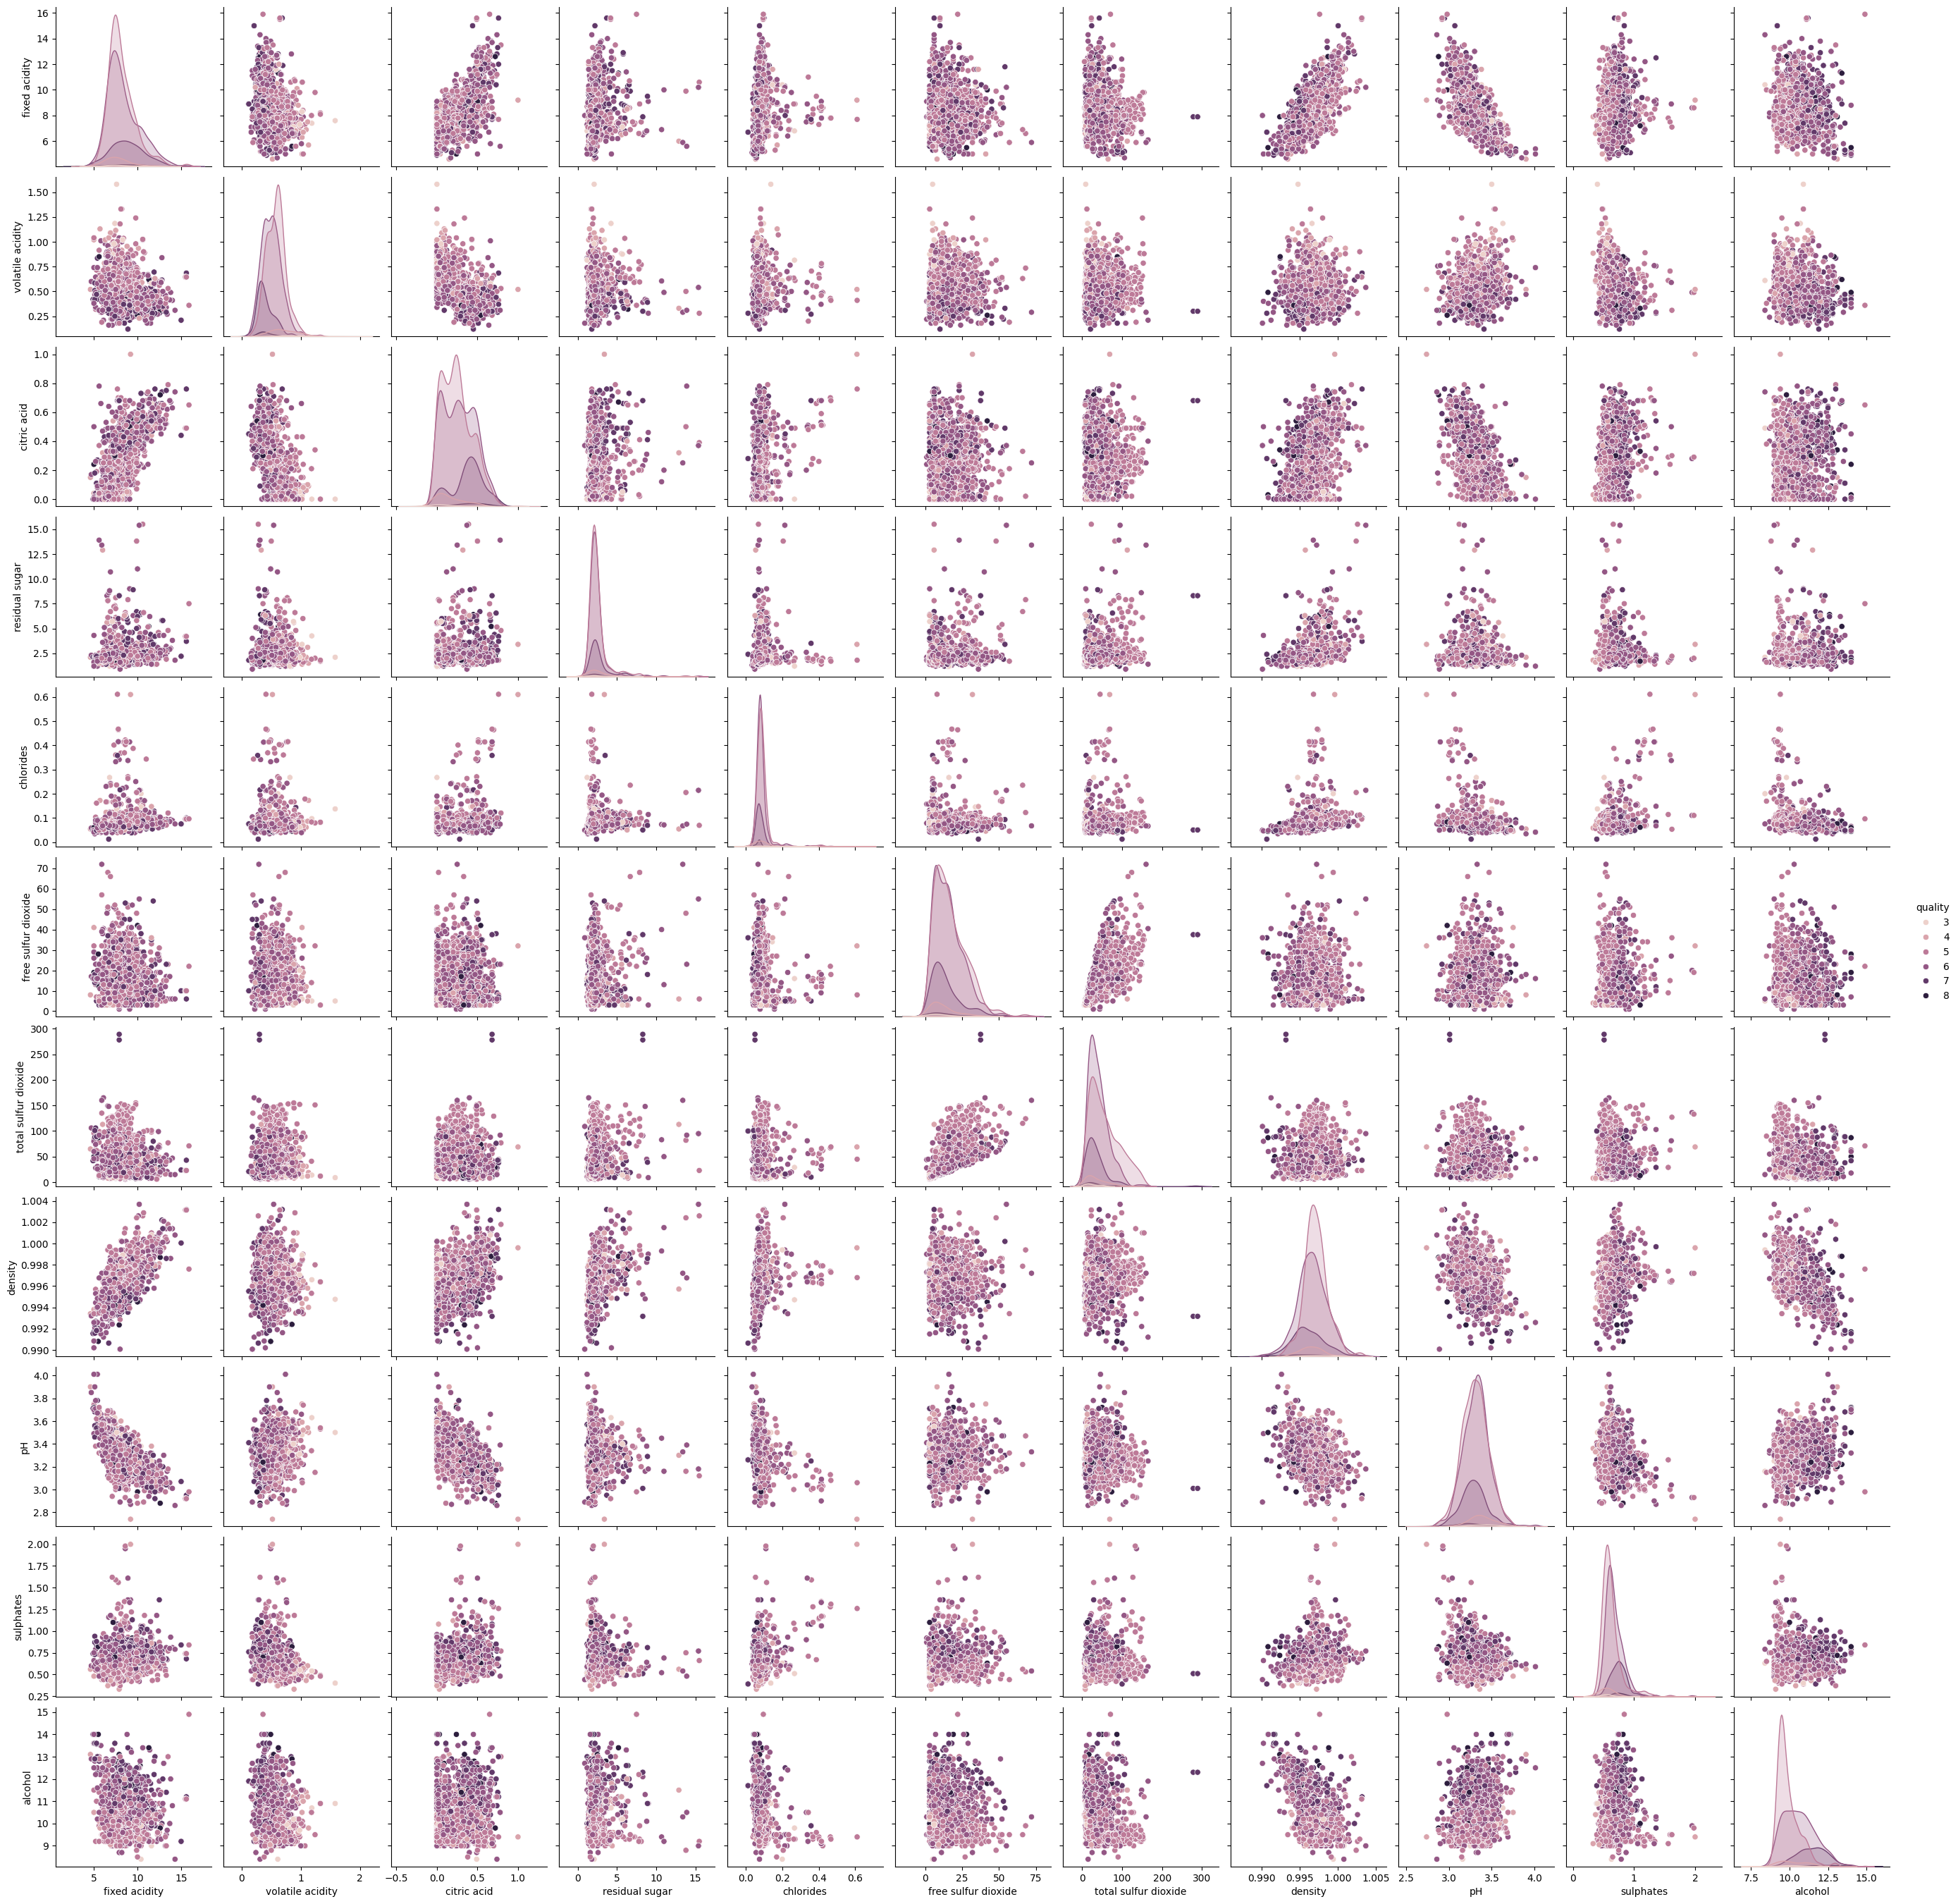

In [29]:
sns.pairplot(data, hue="quality")

Построим "ящики с усами" для pH по качеству

<Axes: xlabel='quality', ylabel='pH'>

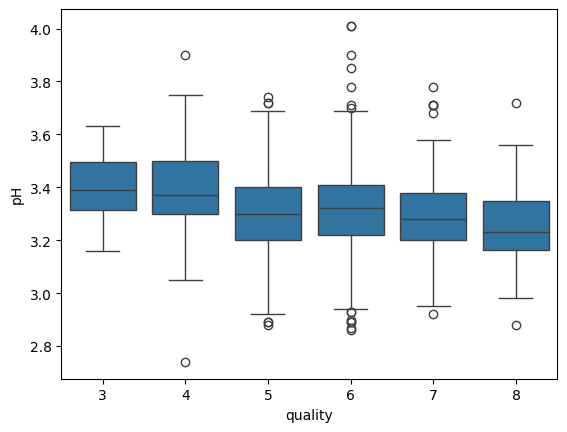

In [30]:
sns.boxplot(x='quality', y='pH', data=data)

Построим корреляционную матрицу

In [31]:
data.corr()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


Построим ткпловую карту для корр матрицы

<Axes: >

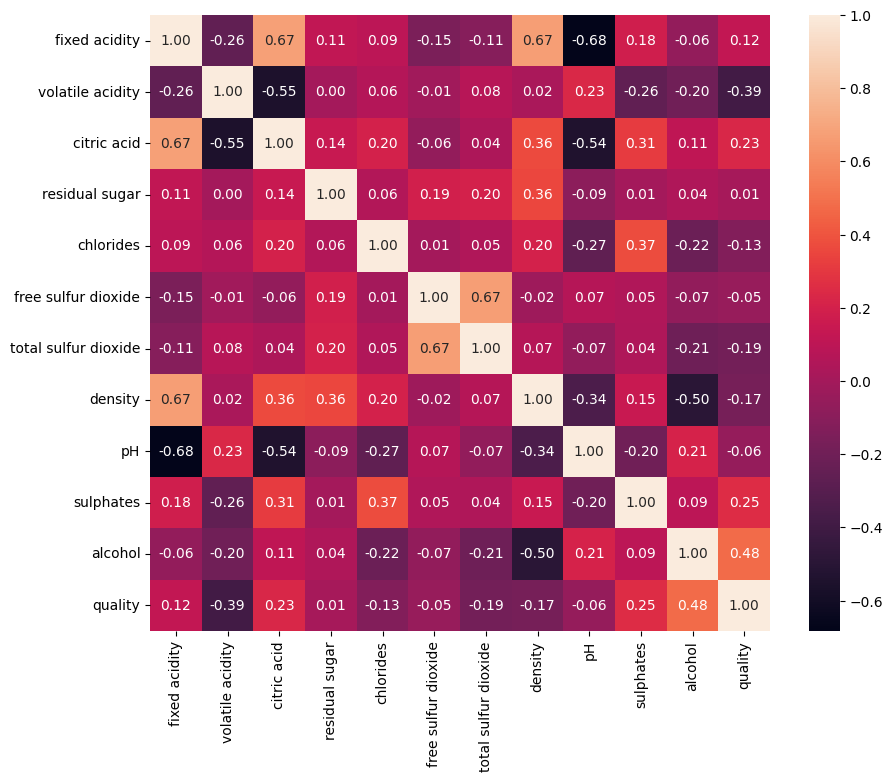

In [32]:
fig, ax = plt.subplots(1, 1, sharex='col', sharey='row', figsize=(10,8))
sns.heatmap(data.corr(), annot=True, fmt='.2f')

Построим "ящики с усами" для каждого признака, а также распределение качества для каждого признака

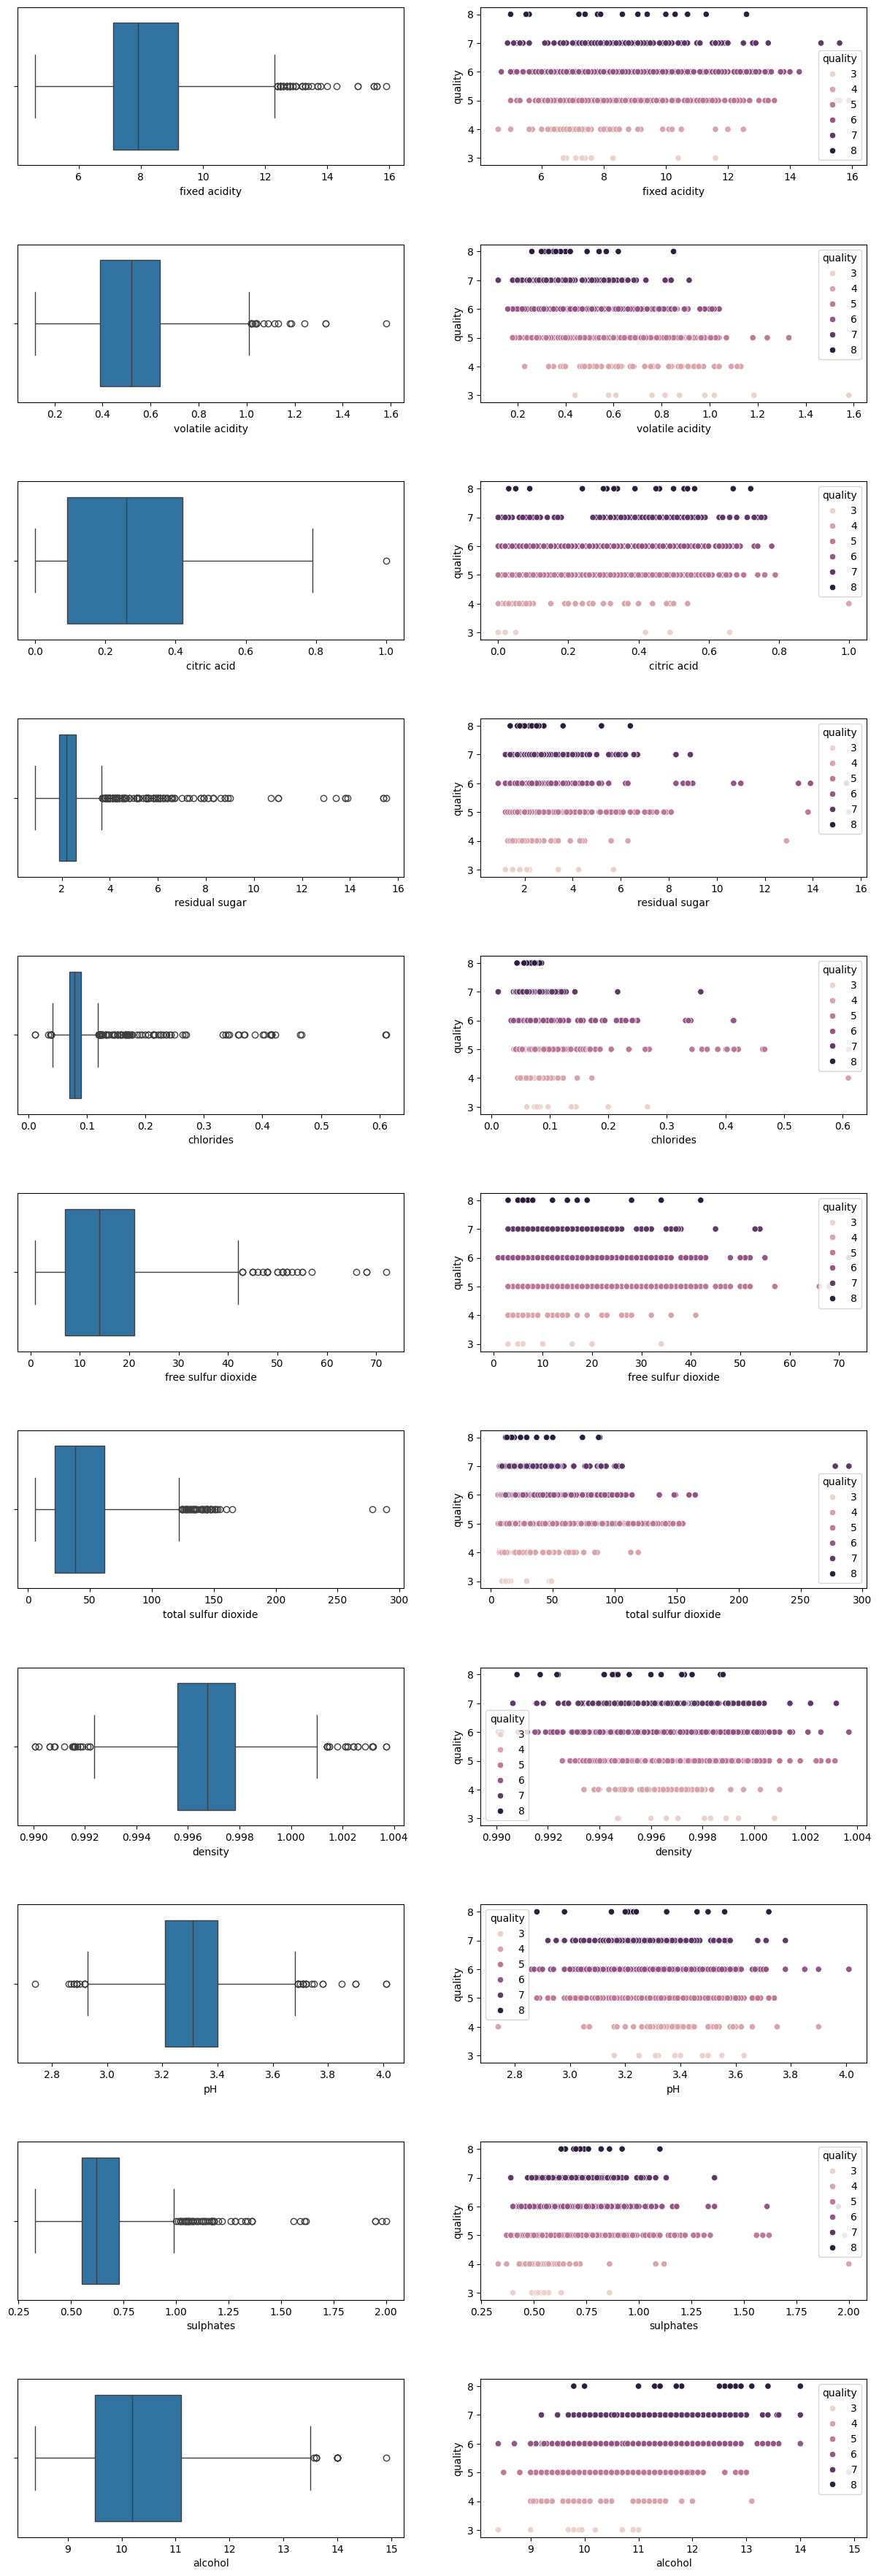

In [33]:
columns = list(data.columns)
fig, ax = plt.subplots(11, 2, figsize=(15, 45))
plt.subplots_adjust(hspace = 0.5)
for i in range(11) :
    # AX 1
    sns.boxplot(x=columns[i], data=data, ax=ax[i, 0])
    # Ax 2
    sns.scatterplot(x=columns[i], y='quality', data=data, hue='quality', ax=ax[i, 1])
